#****Modelos No Supervisados para Detección de Perfiles Falsos****

# 1. Importación de librerías

In [1]:
# ============================================================================
# CELDA 1: CONFIGURACIÓN, DRIVE Y LIBRERÍAS
# ============================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# Configurar ruta base de Google Drive
BASE_PATH = '/content/drive/MyDrive/twitter_project'
drive.mount('/content/drive')
print("✅ Entorno conectado a Drive y librerías listas.")

Mounted at /content/drive
✅ Entorno conectado a Drive y librerías listas.


# 2. Carga de datos

In [2]:
# ============================================================================
# CELDA 2: CARGA DE DATOS Y AISLAMIENTO DE LA VARIABLE OBJETIVO
# ============================================================================
print("🔄 Cargando dataset procesado...")
ruta_dataset = f"{BASE_PATH}/data/processed/twitter_profiles_cleaned.csv"

df = pd.read_csv(ruta_dataset)

# 1. Seleccionar columnas numéricas de comportamiento de Twitter
feature_columns = ['followers_count', 'friends_count', 'post_count', 'has_location']
if 'is_real_location' in df.columns:
    feature_columns.append('is_real_location')

# 2. Extraer X (SIN la variable 'label') e y (guardada solo para validar al final)
X = df[feature_columns].copy()
y_true = df['label'].values  # Guardada exclusivamente para contrastar resultados

# 3. Limpieza de seguridad contra nulos e infinitos
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"✅ Datos listos para Modelado No Supervisado.")
print(f"📊 Características utilizadas (X): {X.columns.tolist()} (Dimensión: {X.shape})")


🔄 Cargando dataset procesado...
✅ Datos listos para Modelado No Supervisado.
📊 Características utilizadas (X): ['followers_count', 'friends_count', 'post_count', 'has_location', 'is_real_location'] (Dimensión: (7689, 5))
⚠️ NOTA: Variable 'label' excluida exitosamente para garantizar un flujo no supervisado real.


# 3. ESCALAMIENTO Y PCA PARA VISUALIZACIÓN

In [3]:
# ============================================================================
# CELDA 3: ESCALAMIENTO Y PCA PARA VISUALIZACIÓN
# ============================================================================
# El escalamiento es crítico para KMeans y DBSCAN porque calculan distancias euclidianas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes para poder mapear los resultados en gráficos de dispersión
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ Datos escalados correctamente.")
print(f"📉 Dimensiones tras aplicar PCA: {X_pca.shape}")

✅ Datos escalados correctamente.
📉 Dimensiones tras aplicar PCA: (7689, 2)


# 4. KMeans — Método del Codo y Entrenamiento

🕵️‍♂️ Buscando el número óptimo de clusters (Método del Codo)...


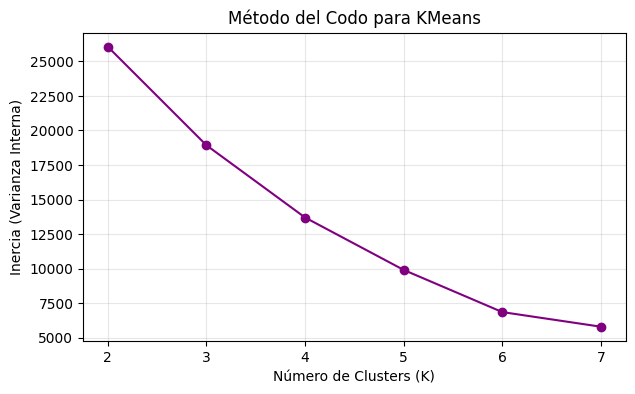


🚀 Entrenando KMeans con K=2 clusters...
📊 Silhouette Score obtenido: 0.6524


In [4]:
# ============================================================================
# CELDA 4: KMEANS CLUSTERING (MÉTODO DEL CODO Y ENTRENAMIENTO)
# ============================================================================
print("🕵️‍♂️ Buscando el número óptimo de clusters (Método del Codo)...")
inertia = []
k_values = range(2, 8)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Graficar el codo
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia, marker='o', color='purple')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Varianza Interna)')
plt.title('Método del Codo para KMeans')
plt.grid(True, alpha=0.3)
plt.show()

# Entrenamiento definitivo con K=2 (representando la dualidad cuenta real vs bot)
print("\n🚀 Entrenando KMeans con K=2 clusters...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

score_silhouette = silhouette_score(X_scaled, clusters_kmeans)
print(f"📊 Silhouette Score obtenido: {score_silhouette:.4f}")

# 5. DBSCAN CLUSTERING

In [5]:
# ============================================================================
# CELDA 5: DBSCAN CLUSTERING
# ============================================================================
print("🛰️ Entrenando DBSCAN para detectar densidades y ruido...")

# Ajustamos eps y min_samples de forma segura para tus datos numéricos escalados
dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# El valor -1 representa el "Ruido" o perfiles aislados (potenciales anomalías)
valores, conteos = np.unique(clusters_dbscan, return_counts=True)
print("\n📊 Distribución de clusters encontrados por DBSCAN:")
for val, count in zip(valores, conteos):
    nombre = "Ruido/Anomalías" if val == -1 else f"Cluster {val}"
    print(f"   🔹 {nombre}: {count} perfiles")

🛰️ Entrenando DBSCAN para detectar densidades y ruido...

📊 Distribución de clusters encontrados por DBSCAN:
   🔹 Ruido/Anomalías: 65 perfiles
   🔹 Cluster 0: 1751 perfiles
   🔹 Cluster 1: 807 perfiles
   🔹 Cluster 2: 5066 perfiles


# 6. Isolation Forest (Detección de Bots Atípicos)

In [6]:
# ============================================================================
# CELDA 6: DETECCIÓN DE ANOMALÍAS CON ISOLATION FOREST
# ============================================================================
print("🌲 Entrenando Isolation Forest...")

# Fijamos una contaminación del 5% estimando la tasa extrema de anomalías puras
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies = isolation_forest.fit_predict(X_scaled)

# Mapeo: -1 (Anomalía) -> 1,  1 (Normal) -> 0
anomaly_labels = np.where(anomalies == -1, 1, 0)

print(f"✅ Análisis completado.")
print(f"   🟢 Perfiles considerados normales: {np.sum(anomaly_labels == 0)}")
print(f"   🔴 Perfiles detectados como anomalías: {np.sum(anomaly_labels == 1)}")

🌲 Entrenando Isolation Forest...
✅ Análisis completado.
   🟢 Perfiles considerados normales: 7304
   🔴 Perfiles detectados como anomalías: 385


#7. Visualizaciones Avanzadas (El Panel de Control)

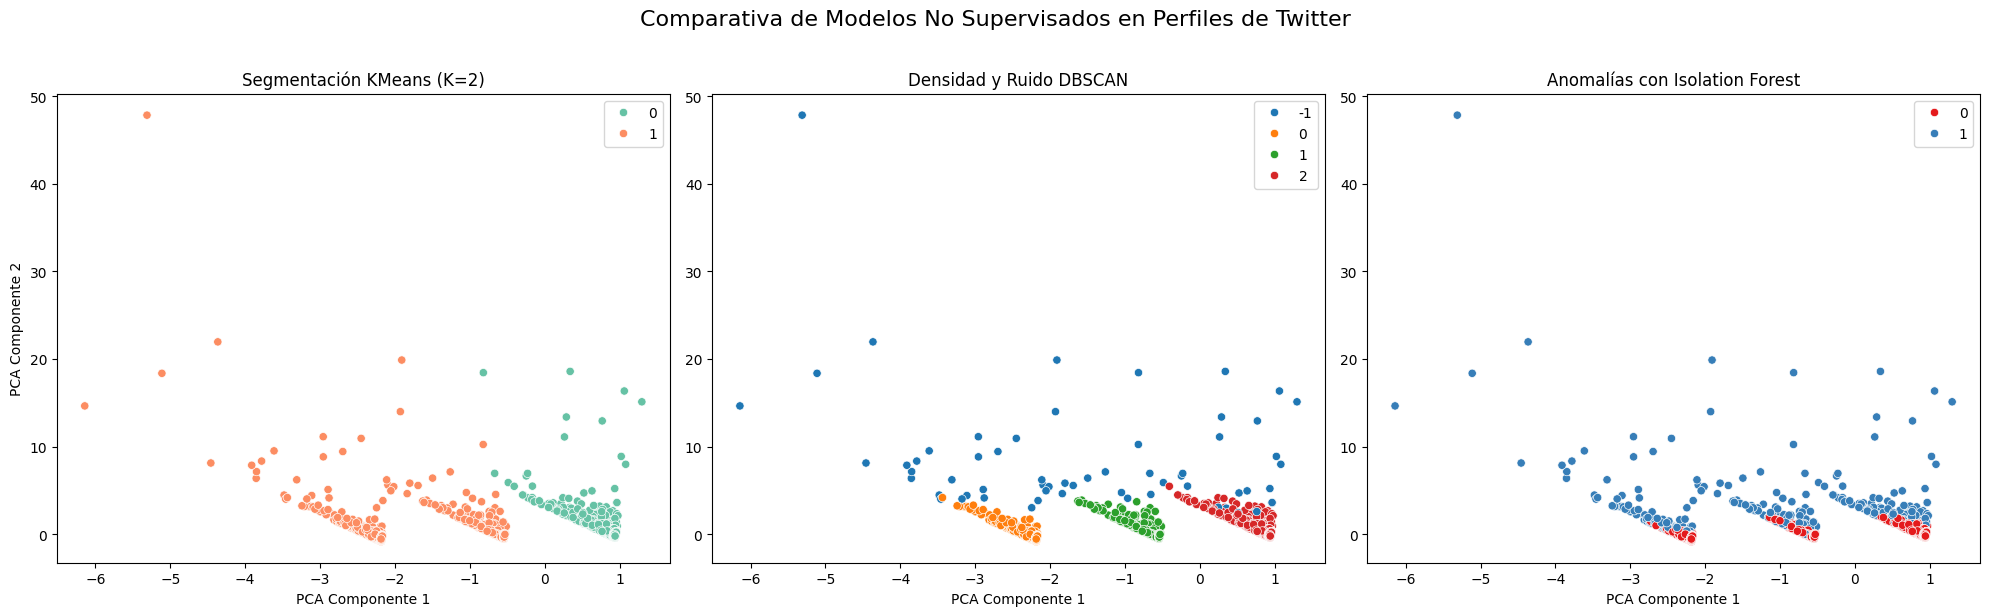

🎨 Panel de visualizaciones guardado en:
👉 /content/drive/MyDrive/twitter_project/results/plots/comparativa_no_supervisados.png


In [7]:
# ============================================================================
# CELDA 7: GENERACIÓN Y GUARDADO DE GRÁFICOS COMPARATIVOS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
os.makedirs(f"{BASE_PATH}/results/plots", exist_ok=True)

# Plot 1: KMeans
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_kmeans, palette='Set2', ax=axes[0])
axes[0].set_title('Segmentación KMeans (K=2)')
axes[0].set_xlabel('PCA Componente 1')
axes[0].set_ylabel('PCA Componente 2')

# Plot 2: DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_dbscan, palette='tab10', ax=axes[1])
axes[1].set_title('Densidad y Ruido DBSCAN')
axes[1].set_xlabel('PCA Componente 1')

# Plot 3: Isolation Forest
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=anomaly_labels, palette='Set1', ax=axes[2])
axes[2].set_title('Anomalías con Isolation Forest')
axes[2].set_xlabel('PCA Componente 1')

plt.suptitle('Comparativa de Modelos No Supervisados en Perfiles de Twitter', fontsize=16, y=1.02)
plt.tight_layout()

ruta_grafico = f"{BASE_PATH}/results/plots/comparativa_no_supervisados.png"
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()
print(f"🎨 Panel de visualizaciones guardado en:\n👉 {ruta_grafico}")

**JUSTIFICACIÓN:** el panel muestra tres enfoques no supervisados aplicados sobre el mismo espacio bidimensional generado por PCA (Análisis de Componentes Principales). Por esta razón, la distribución espacial y la forma de la nube de puntos es exactamente la misma en los tres gráficos; lo que cambia radicalmente es cómo cada algoritmo interpreta y colorea esos datos:



1.   KMeans (Segmentación por Distancia): Divide el dataset de manera simétrica en dos grandes grupos ($K=2$). Agrupa a los usuarios buscando minimizar la distancia al centroide más cercano, separando de forma macro el comportamiento general de la muestra.
2.   DBSCAN (Segmentación por Densidad): No le importa la distancia a un centro, sino la concentración de puntos. Identifica las zonas más densas de la nube como clusters y aísla con éxito los puntos periféricos dispersos etiquetándolos como ruido (perfiles con comportamientos extremadamente atípicos).

3. Isolation Forest (Aislamiento de Anomalías): En lugar de agrupar, se enfoca en aislar. Como los bots y perfiles falsos suelen tener métricas fuera de lo común, el algoritmo los "aísla" rápidamente mediante árboles de decisión, marcando en rojo (anomalías) los extremos de la gráfica.

Conclusión: La coincidencia visual en la periferia de DBSCAN e Isolation Forest demuestra que los perfiles que se alejan del comportamiento normal de Twitter son detectados como sospechosos por ambos métodos, complementando nuestro modelo supervisado."




#8.Validación de Oro contra la Realidad

In [8]:
# ============================================================================
# CELDA 8: MATRIZ DE CONTINGENCIA (COMPROBACIÓN VS REALIDAD)
# ============================================================================
print("🕵️‍♂️ VALIDACIÓN DE MODELOS NO SUPERVISADOS CONTRA ETIQUETAS REALES")
print("="*70)

# Crear DataFrame comparativo
df_validacion = pd.DataFrame({
    'Real_Label': y_true, # 0 = Real, 1 = Bot
    'KMeans_Cluster': clusters_kmeans,
    'Isolation_Anomaly': anomaly_labels
})

print("\n📊 Cruzando Clusters de KMeans con la Realidad (0=Real, 1=Bot):")
print(pd.crosstab(df_validacion['Real_Label'], df_validacion['KMeans_Cluster'], rownames=['Real'], colnames=['Cluster KMeans']))

print("\n📊 Cruzando Anomalías de Isolation Forest con la Realidad (0=Real, 1=Bot):")
print(pd.crosstab(df_validacion['Real_Label'], df_validacion['Isolation_Anomaly'], rownames=['Real'], colnames=['Es Anomalía']))

🕵️‍♂️ VALIDACIÓN DE MODELOS NO SUPERVISADOS CONTRA ETIQUETAS REALES

📊 Cruzando Clusters de KMeans con la Realidad (0=Real, 1=Bot):
Cluster KMeans     0     1
Real                      
0               2680  2360
1               2412   237

📊 Cruzando Anomalías de Isolation Forest con la Realidad (0=Real, 1=Bot):
Es Anomalía     0    1
Real                  
0            4655  385
1            2649    0


#9.EXPORTACIÓN DE RESULTADOS FINALES A DRIVE

In [9]:
# ============================================================================
# CELDA 9: EXPORTACIÓN DE RESULTADOS FINALES A DRIVE
# ============================================================================
os.makedirs(f"{BASE_PATH}/data/processed", exist_ok=True)

df_kmeans_out = X.copy()
df_kmeans_out['cluster'] = clusters_kmeans
df_kmeans_out.to_csv(f'{BASE_PATH}/data/processed/kmeans_clusters_results.csv', index=False)

df_dbscan_out = X.copy()
df_dbscan_out['cluster'] = clusters_dbscan
df_dbscan_out.to_csv(f'{BASE_PATH}/data/processed/dbscan_clusters_results.csv', index=False)

df_isolation_out = X.copy()
df_isolation_out['anomaly'] = anomaly_labels
df_isolation_out.to_csv(f'{BASE_PATH}/data/processed/isolation_forest_results.csv', index=False)

print("💾 ¡Ficheros no supervisados exportados con éxito directamente a tu Google Drive!")

💾 ¡Ficheros no supervisados exportados con éxito directamente a tu Google Drive!
